**Taller — Limpieza y Análisis de Datos con Pandas y NumPy**

Objetivo
Aplicar técnicas de limpieza, transformación y análisis de datos utilizando las librerías Pandas y NumPy a partir de una base de datos con inconsistencias similares a escenarios reales.


**Archivos entregados**
ventas_sucias_5000.csv

Instrucciones generales
•
Trabajar en un notebook de Jupyter (.ipynb) o script .py
•
El código debe estar comentado y organizado
•
Cada respuesta debe incluir:
•
Código
•
Explicación breve del resultado obtenido
•
Justificar decisiones de limpieza cuando sea necesario

0. importar librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Parte 1 — Exploración de datos (Pandas)**

1. Cargar base de datos

In [31]:
df_ventas_sucias = pd.read_csv("C:\\Users\\juan1\\Downloads\\ventas_sucias_5000.csv")

display(df_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha
0,Maria,Monitor,1326.0,NaN,peru,Efectivo,2024-01-01 00:00:00
1,Luisa,Laptop,55.0,2,chile,Tarjeta,2024-01-01 01:00:00
2,Carlos,Monitor,1203.0,9,Colombia,Efectivo,2024-01-01 02:00:00
3,Luisa,Monitor,1304.0,3,Perú,TRANSFERENCIA,2024-01-01 03:00:00
4,Luisa,Monitor,426.0,6,chile,Tarjeta,2024-01-01 04:00:00
...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8,chile,transferencia,2024-07-27 03:00:00
4996,Carlos,Mouse,1553.0,2,Perú,Tarjeta,2024-07-27 04:00:00
4997,Juan,Monitor,1776.0,2,chile,Efectivo,2024-07-27 05:00:00
4998,Pedro,Laptop,1366.0,8,Chile,TRANSFERENCIA,2024-07-27 06:00:00


2. Mostrar primeras filas

In [32]:
df_ventas_sucias.head()

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha
0,Maria,Monitor,1326.0,NaN,peru,Efectivo,2024-01-01 00:00:00
1,Luisa,Laptop,55.0,2,chile,Tarjeta,2024-01-01 01:00:00
2,Carlos,Monitor,1203.0,9,Colombia,Efectivo,2024-01-01 02:00:00
3,Luisa,Monitor,1304.0,3,Perú,TRANSFERENCIA,2024-01-01 03:00:00
4,Luisa,Monitor,426.0,6,chile,Tarjeta,2024-01-01 04:00:00


3. Información general del dataset

In [33]:
## con info

df_ventas_sucias.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cliente      5000 non-null   str    
 1   producto     5000 non-null   str    
 2   precio       4950 non-null   float64
 3   cantidad     4950 non-null   str    
 4   pais         5000 non-null   str    
 5   metodo_pago  5000 non-null   str    
 6   fecha        5000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 273.6 KB


In [34]:
## con describe

df_ventas_sucias.describe()

,precio
count,4950.000000
mean,5053.823434
std,63379.982009
min,10.000000
25%,531.000000
50%,1027.000000
75%,1519.000000
max,999999.000000


In [35]:
## con shape

df_ventas_sucias.shape

(5000, 7)

**RESUMEN**

Tenemos una dataframe con **7 columnas** y **5000 filas**. Tenemos dos tipos de datos:

String y float. Sin embargo, debemos hacer transformaciones de datos y limpiezas de los mismos. 

4. Rastreo de datos nullos o inconsistentes.

In [36]:
##datos unicos productos

datos_unicos_producto = df_ventas_sucias.producto.unique()

print(datos_unicos_producto)

## datos unicos precio 

datos_unicos_precio = df_ventas_sucias.precio.unique()

print(datos_unicos_precio)

## datos unicos cantidad

datos_unicos_cantidad = df_ventas_sucias.cantidad.unique()

print(datos_unicos_cantidad)

## con paises

datos_unicos_pais = df_ventas_sucias.pais.unique()

print(datos_unicos_pais)

## con paises

datos_unicos_metodo_pago = df_ventas_sucias.metodo_pago.unique()

print(datos_unicos_metodo_pago)

## con paises

datos_unicos_fecha = df_ventas_sucias.fecha.unique()

print(datos_unicos_fecha)





<StringArray>
['Monitor', 'Laptop', 'Celular', 'Mouse', 'Teclado']
Length: 5, dtype: str
[1326.   55. 1203. ... 1788. 1019. 1672.]
<StringArray>
[nan, '2', '9', '3', '6', '7', '1', '8', '5', '4', 'three']
Length: 11, dtype: str
<StringArray>
['peru', 'chile', 'Colombia', 'Perú', 'COL', 'Chile', 'col']
Length: 7, dtype: str
<StringArray>
['Efectivo', 'Tarjeta', 'TRANSFERENCIA', 'transferencia']
Length: 4, dtype: str
<StringArray>
['2024-01-01 00:00:00', '2024-01-01 01:00:00', '2024-01-01 02:00:00',
 '2024-01-01 03:00:00', '2024-01-01 04:00:00', '2024-01-01 05:00:00',
 '2024-01-01 06:00:00', '2024-01-01 07:00:00', '2024-01-01 08:00:00',
 '2024-01-01 09:00:00',
 ...
 '2024-07-26 21:00:00', '2024-07-26 22:00:00', '2024-07-26 23:00:00',
 '2024-07-27 00:00:00', '2024-07-27 01:00:00', '2024-07-27 02:00:00',
 '2024-07-27 03:00:00', '2024-07-27 04:00:00', '2024-07-27 05:00:00',
 '2024-07-27 06:00:00']
Length: 4825, dtype: str


In [37]:
## con numpy
datos_unicos = df_ventas_sucias.nunique()


**DUPLICAR TABLA PARA TRABAJAR SOBRE LA DUPLICADA**

In [38]:
df1_ventas_sucias = df_ventas_sucias.copy()

**CORRECION DE DATOS**

5. Corregir tipos de datos incorrectos

In [39]:
## correccion del error en cantidad

df1_ventas_sucias["cantidad"] = df1_ventas_sucias["cantidad"].replace("three","3")

## reemplazar nan en precio

df1_ventas_sucias["cantidad"] = pd.to_numeric(df1_ventas_sucias["cantidad"],errors="coerce")

df1_ventas_sucias = df1_ventas_sucias[df1_ventas_sucias["cantidad"].notna()]

display(df1_ventas_sucias)

contar_valores_cantidad = df1_ventas_sucias["cantidad"].value_counts(dropna=False)

print(contar_valores_cantidad)



## correccion del error en pais

df1_ventas_sucias["pais"] = df1_ventas_sucias["pais"].replace({"COL":"Colombia",
                                                               "col":"Colombia",
                                                               "Perú":"peru",})
df1_ventas_sucias["pais"] = df1_ventas_sucias["pais"].str.capitalize()

unicos_pais = df1_ventas_sucias["pais"].value_counts(dropna=False)
print(unicos_pais)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha
1,Luisa,Laptop,55.0,2.0,chile,Tarjeta,2024-01-01 01:00:00
2,Carlos,Monitor,1203.0,9.0,Colombia,Efectivo,2024-01-01 02:00:00
3,Luisa,Monitor,1304.0,3.0,Perú,TRANSFERENCIA,2024-01-01 03:00:00
4,Luisa,Monitor,426.0,6.0,chile,Tarjeta,2024-01-01 04:00:00
5,Juan,Laptop,857.0,6.0,COL,transferencia,2024-01-01 05:00:00
...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,chile,transferencia,2024-07-27 03:00:00
4996,Carlos,Mouse,1553.0,2.0,Perú,Tarjeta,2024-07-27 04:00:00
4997,Juan,Monitor,1776.0,2.0,chile,Efectivo,2024-07-27 05:00:00
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27 06:00:00


cantidad
3.0    596
2.0    573
4.0    557
8.0    553
1.0    550
7.0    540
6.0    539
5.0    526
9.0    516
Name: count, dtype: int64
pais
Colombia    2114
Chile       1445
Peru        1391
Name: count, dtype: int64


6. **ARREGLO COLUMNA FECHA** 

Para arreglar la columna fecha, e identificando que se concentra también la hora (la cual puede servir más adelante).

In [40]:
## separar columnas por espacio

df1_ventas_sucias[["fecha","hora"]]= df1_ventas_sucias["fecha"].str.split(" ",expand=True)

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora
1,Luisa,Laptop,55.0,2.0,Chile,Tarjeta,2024-01-01,01:00:00
2,Carlos,Monitor,1203.0,9.0,Colombia,Efectivo,2024-01-01,02:00:00
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00
4,Luisa,Monitor,426.0,6.0,Chile,Tarjeta,2024-01-01,04:00:00
5,Juan,Laptop,857.0,6.0,Colombia,transferencia,2024-01-01,05:00:00
...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,transferencia,2024-07-27,03:00:00
4996,Carlos,Mouse,1553.0,2.0,Peru,Tarjeta,2024-07-27,04:00:00
4997,Juan,Monitor,1776.0,2.0,Chile,Efectivo,2024-07-27,05:00:00
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00


In [41]:
## convertir a fecha y hora

df1_ventas_sucias["fecha"] = pd.to_datetime(df1_ventas_sucias["fecha"], errors = "coerce")
df1_ventas_sucias["hora"] = pd.to_datetime(df1_ventas_sucias["hora"],format='%H:%M:%S',errors = "coerce").dt.time
df1_ventas_sucias["mes"] = df1_ventas_sucias["fecha"].dt.month

df1_ventas_sucias.info()

display(df1_ventas_sucias)


<class 'pandas.DataFrame'>
Index: 4950 entries, 1 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cliente      4950 non-null   str           
 1   producto     4950 non-null   str           
 2   precio       4903 non-null   float64       
 3   cantidad     4950 non-null   float64       
 4   pais         4950 non-null   str           
 5   metodo_pago  4950 non-null   str           
 6   fecha        4950 non-null   datetime64[us]
 7   hora         4950 non-null   object        
 8   mes          4950 non-null   int32         
dtypes: datetime64[us](1), float64(2), int32(1), object(1), str(4)
memory usage: 367.4+ KB


,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes
1,Luisa,Laptop,55.0,2.0,Chile,Tarjeta,2024-01-01,01:00:00,1
2,Carlos,Monitor,1203.0,9.0,Colombia,Efectivo,2024-01-01,02:00:00,1
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00,1
4,Luisa,Monitor,426.0,6.0,Chile,Tarjeta,2024-01-01,04:00:00,1
5,Juan,Laptop,857.0,6.0,Colombia,transferencia,2024-01-01,05:00:00,1
...,...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,transferencia,2024-07-27,03:00:00,7
4996,Carlos,Mouse,1553.0,2.0,Peru,Tarjeta,2024-07-27,04:00:00,7
4997,Juan,Monitor,1776.0,2.0,Chile,Efectivo,2024-07-27,05:00:00,7
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00,7


In [42]:
## convertir a formato fecha.

valores_fecha = df1_ventas_sucias["fecha"].value_counts(dropna=False)

print(valores_fecha)

fecha
2024-06-02    26
2024-03-07    26
2024-05-07    26
2024-02-01    25
2024-03-04    25
              ..
2024-10-05     1
2024-11-05     1
2024-08-07     1
2024-09-07     1
2024-11-07     1
Name: count, Length: 225, dtype: int64


**ARREGLO COLUMNA METODO_PAGO**

In [43]:
## CONVERTIR A MAYUSCULA

df1_ventas_sucias["metodo_pago"]= df1_ventas_sucias["metodo_pago"].str.upper()

unicos_metodo = df1_ventas_sucias["metodo_pago"].value_counts(dropna=False)

print(unicos_metodo)

display(df1_ventas_sucias)  

metodo_pago
TRANSFERENCIA    2507
EFECTIVO         1237
TARJETA          1206
Name: count, dtype: int64


,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes
1,Luisa,Laptop,55.0,2.0,Chile,TARJETA,2024-01-01,01:00:00,1
2,Carlos,Monitor,1203.0,9.0,Colombia,EFECTIVO,2024-01-01,02:00:00,1
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00,1
4,Luisa,Monitor,426.0,6.0,Chile,TARJETA,2024-01-01,04:00:00,1
5,Juan,Laptop,857.0,6.0,Colombia,TRANSFERENCIA,2024-01-01,05:00:00,1
...,...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,TRANSFERENCIA,2024-07-27,03:00:00,7
4996,Carlos,Mouse,1553.0,2.0,Peru,TARJETA,2024-07-27,04:00:00,7
4997,Juan,Monitor,1776.0,2.0,Chile,EFECTIVO,2024-07-27,05:00:00,7
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00,7


In [44]:
## contar valores nulos de precio por producto

unicos_precio_producto = df1_ventas_sucias.groupby("producto")["precio"].apply(lambda x: x.isna().sum())

print(unicos_precio_producto)

producto
Celular     9
Laptop      9
Monitor     8
Mouse      10
Teclado    11
Name: precio, dtype: int64


**TECNICAS DE AUTOCOMPLETAR VALORES FALTANTES NUMERICOS**

MEDIANA POR PRODUCTO

In [ ]:
df1_ventas_sucias["precio_mediana"] = df1_ventas_sucias.groupby(["producto","pais"])["precio"].transform('median')

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana
1,Luisa,Laptop,55.0,2.0,Chile,TARJETA,2024-01-01,01:00:00,1,984.0
2,Carlos,Monitor,1203.0,9.0,Colombia,EFECTIVO,2024-01-01,02:00:00,1,1438.0
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00,1,1155.0
4,Luisa,Monitor,426.0,6.0,Chile,TARJETA,2024-01-01,04:00:00,1,964.0
5,Juan,Laptop,857.0,6.0,Colombia,TRANSFERENCIA,2024-01-01,05:00:00,1,966.0
...,...,...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,TRANSFERENCIA,2024-07-27,03:00:00,7,776.5
4996,Carlos,Mouse,1553.0,2.0,Peru,TARJETA,2024-07-27,04:00:00,7,1119.0
4997,Juan,Monitor,1776.0,2.0,Chile,EFECTIVO,2024-07-27,05:00:00,7,1009.0
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00,7,776.5


**POR PROMEDIO**

In [46]:
df1_ventas_sucias["precio_promedio"] = df1_ventas_sucias.groupby(["producto","pais"])["precio"].transform('mean')

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio
1,Luisa,Laptop,55.0,2.0,Chile,TARJETA,2024-01-01,01:00:00,1,984.0,982.876404
2,Carlos,Monitor,1203.0,9.0,Colombia,EFECTIVO,2024-01-01,02:00:00,1,1438.0,3357.352804
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00,1,1155.0,1034.019455
4,Luisa,Monitor,426.0,6.0,Chile,TARJETA,2024-01-01,04:00:00,1,964.0,7935.566434
5,Juan,Laptop,857.0,6.0,Colombia,TRANSFERENCIA,2024-01-01,05:00:00,1,966.0,5655.099537
...,...,...,...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,TRANSFERENCIA,2024-07-27,03:00:00,7,776.5,982.876404
4996,Carlos,Mouse,1553.0,2.0,Peru,TARJETA,2024-07-27,04:00:00,7,1119.0,7264.749216
4997,Juan,Monitor,1776.0,2.0,Chile,EFECTIVO,2024-07-27,05:00:00,7,1009.0,7935.566434
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00,7,776.5,982.876404


In [47]:
## columna final de precio

df1_ventas_sucias["precio_final"] = df1_ventas_sucias["precio"].fillna(df1_ventas_sucias["precio_mediana"])
display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final
1,Luisa,Laptop,55.0,2.0,Chile,TARJETA,2024-01-01,01:00:00,1,984.0,982.876404,55.0
2,Carlos,Monitor,1203.0,9.0,Colombia,EFECTIVO,2024-01-01,02:00:00,1,1438.0,3357.352804,1203.0
3,Luisa,Monitor,1304.0,3.0,Peru,TRANSFERENCIA,2024-01-01,03:00:00,1,1155.0,1034.019455,1304.0
4,Luisa,Monitor,426.0,6.0,Chile,TARJETA,2024-01-01,04:00:00,1,964.0,7935.566434,426.0
5,Juan,Laptop,857.0,6.0,Colombia,TRANSFERENCIA,2024-01-01,05:00:00,1,966.0,5655.099537,857.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Juan,Laptop,1582.0,8.0,Chile,TRANSFERENCIA,2024-07-27,03:00:00,7,776.5,982.876404,1582.0
4996,Carlos,Mouse,1553.0,2.0,Peru,TARJETA,2024-07-27,04:00:00,7,1119.0,7264.749216,1553.0
4997,Juan,Monitor,1776.0,2.0,Chile,EFECTIVO,2024-07-27,05:00:00,7,1009.0,7935.566434,1776.0
4998,Pedro,Laptop,1366.0,8.0,Chile,TRANSFERENCIA,2024-07-27,06:00:00,7,776.5,982.876404,1366.0


**VALORES ESTADISTICOS**

In [48]:
df1_ventas_sucias.describe()

,precio,cantidad,fecha,mes,precio_mediana,precio_promedio,precio_final
count,4903.000000,4950.000000,4950,4950.000000,4950.000000,4950.000000,4950.000000
mean,5091.201509,4.934141,2024-04-14 10:13:49.090909,3.967879,1227.649293,5092.322756,5052.507071
min,10.000000,1.000000,2024-01-01 00:00:00,1.000000,34.000000,982.876404,10.000000
25%,531.000000,3.000000,2024-02-22 00:00:00,2.000000,952.000000,3357.352804,537.000000
50%,1027.000000,5.000000,2024-04-14 00:00:00,4.000000,1034.500000,5655.099537,1027.000000
75%,1517.000000,7.000000,2024-06-05 00:00:00,6.000000,1114.000000,7935.566434,1512.750000
max,999999.000000,9.000000,2024-12-04 00:00:00,12.000000,500061.000000,8964.557769,999999.000000
std,63681.912130,2.574748,NaN,2.005745,10031.116813,2781.680719,63380.035413


### Organizar por PAIS, PRODUCTO, MES 

In [49]:
df1_ventas_sucias = df1_ventas_sucias.sort_values(by=["pais","producto","mes"])

display(df1_ventas_sucias)  

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0


<h1>**DETECTAR DATOS ATIPICOS (OUTLIERS)**<h1/>

Se aplicará la técnica de rango intercuartílico  

IQR=Q3−Q1
Límite inferior: Q1−1.5⋅IQR
Límite superior: Q3+1.5⋅IQR



## **Q1**

In [50]:
## vamos a clacular los cuartiles de precio final

df1_ventas_sucias["Q1_precio_final"] = df1_ventas_sucias.groupby(["producto","pais"])["precio_final"].transform(lambda x: x.quantile(0.25))

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0,561.0
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0,561.0
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0,561.0
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0,561.0
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0,561.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0,546.0
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0,546.0
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0,546.0
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0,546.0


## **Q3**

In [51]:
## calculamos el quartil 3

df1_ventas_sucias["Q3_precio_final"] = df1_ventas_sucias.groupby(["producto","pais"])["precio_final"].transform(lambda x: x.quantile(0.75))

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0,561.0,1556.75
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0,561.0,1556.75
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0,561.0,1556.75
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0,561.0,1556.75
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0,561.0,1556.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0,546.0,1516.00
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0,546.0,1516.00
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0,546.0,1516.00
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0,546.0,1516.00


## **IQR (rango intercuartilico)**

IQR = Q3-Q1

In [52]:
df1_ventas_sucias["IQR"]= df1_ventas_sucias["Q3_precio_final"] - df1_ventas_sucias["Q1_precio_final"]
display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final,IQR
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0,561.0,1556.75,995.75
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0,561.0,1556.75,995.75
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0,561.0,1556.75,995.75
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0,561.0,1556.75,995.75
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0,561.0,1556.75,995.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0,546.0,1516.00,970.00
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0,546.0,1516.00,970.00
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0,546.0,1516.00,970.00
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0,546.0,1516.00,970.00


## Limite Inferior y Límite Superior

lim_inf = Q1 - 1.5 * IQR |
lim_sup = Q3 + 1.5 * IQR


In [53]:
df1_ventas_sucias["L.I"] = df1_ventas_sucias["Q1_precio_final"] - 1.5*df1_ventas_sucias["IQR"]
df1_ventas_sucias["L.S"] = df1_ventas_sucias["Q3_precio_final"] + 1.5*df1_ventas_sucias["IQR"]
display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final,IQR,L.I,L.S
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0,561.0,1556.75,995.75,-932.625,3050.375
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0,561.0,1556.75,995.75,-932.625,3050.375
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0,561.0,1556.75,995.75,-932.625,3050.375
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0,561.0,1556.75,995.75,-932.625,3050.375
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0,561.0,1556.75,995.75,-932.625,3050.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0,546.0,1516.00,970.00,-909.000,2971.000
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0,546.0,1516.00,970.00,-909.000,2971.000
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0,546.0,1516.00,970.00,-909.000,2971.000
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0,546.0,1516.00,970.00,-909.000,2971.000


## **OUTLIERS** 

Si están fuera de los limites, son datos atípicos conocidos como outliers

vamos a utilizar la libreria NP con la sentencia WHERE

In [54]:
df1_ventas_sucias["outlier"] = np.where(df1_ventas_sucias["precio_final"]< df1_ventas_sucias["L.I"],"outlier",np.where(df1_ventas_sucias["precio_final"]> df1_ventas_sucias["L.S"],"outlier","no_outlier"))

display(df1_ventas_sucias)

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final,IQR,L.I,L.S,outlier
7,Carlos,Celular,256.0,7.0,Chile,TARJETA,2024-01-01,07:00:00,1,730.5,7948.896194,256.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
10,Maria,Celular,801.0,8.0,Chile,TRANSFERENCIA,2024-01-01,10:00:00,1,730.5,7948.896194,801.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
13,Luisa,Celular,383.0,8.0,Chile,TARJETA,2024-01-01,13:00:00,1,730.5,7948.896194,383.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
36,Pedro,Celular,1576.0,9.0,Chile,TRANSFERENCIA,2024-01-02,12:00:00,1,730.5,7948.896194,1576.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
64,Ana,Celular,1664.0,2.0,Chile,EFECTIVO,2024-01-03,16:00:00,1,730.5,7948.896194,1664.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,Maria,Teclado,255.0,9.0,Peru,EFECTIVO,2024-07-23,15:00:00,7,1112.5,8964.557769,255.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
4924,Ana,Teclado,1089.0,1.0,Peru,TARJETA,2024-07-24,04:00:00,7,1112.5,8964.557769,1089.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
4936,Ana,Teclado,1866.0,8.0,Peru,TARJETA,2024-07-24,16:00:00,7,1112.5,8964.557769,1866.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
4978,Maria,Teclado,1672.0,1.0,Peru,TARJETA,2024-07-26,10:00:00,7,1112.5,8964.557769,1672.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier


<Axes: xlabel='precio_final', ylabel='cantidad'>

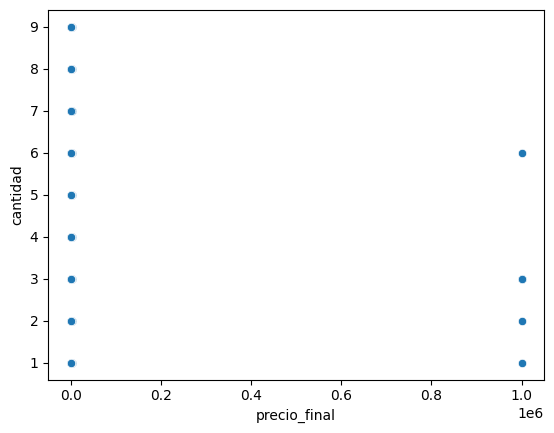

In [75]:
##['Monitor', 'Laptop', 'Celular', 'Mouse', 'Teclado']

df1_celular_chile = df1_ventas_sucias[(df1_ventas_sucias["producto"]=="Celular")&(df1_ventas_sucias["pais"]=="Chile")]

sns.scatterplot(data=df1_celular,x="precio_final",y="cantidad")

In [55]:
conteto_atipicos=df1_ventas_sucias.value_counts("outlier")

print(conteto_atipicos)

df1_filtrado_atipicos = df1_ventas_sucias[df1_ventas_sucias["outlier"]=="outlier"]

display(df1_filtrado_atipicos)

outlier
no_outlier    4930
outlier         20
Name: count, dtype: int64


,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final,IQR,L.I,L.S,outlier
1277,Pedro,Celular,999999.0,3.0,Chile,TARJETA,2024-02-23,05:00:00,2,1080.0,7948.896194,999999.0,561.00,1556.75,995.75,-932.625,3050.375,outlier
2976,Carlos,Celular,999999.0,6.0,Chile,TARJETA,2024-05-04,00:00:00,5,1147.0,7948.896194,999999.0,561.00,1556.75,995.75,-932.625,3050.375,outlier
2144,Ana,Monitor,999999.0,3.0,Chile,TRANSFERENCIA,2024-03-30,08:00:00,3,911.0,7935.566434,999999.0,454.00,1430.00,976.00,-1010.000,2894.000,outlier
3868,Pedro,Monitor,999999.0,3.0,Chile,TRANSFERENCIA,2024-10-06,00:00:00,10,500061.0,7935.566434,999999.0,454.00,1430.00,976.00,-1010.000,2894.000,outlier
1165,Luisa,Mouse,999999.0,3.0,Chile,TARJETA,2024-02-18,13:00:00,2,1208.0,7478.445161,999999.0,501.50,1547.00,1045.50,-1066.750,3115.250,outlier
4104,Pedro,Mouse,999999.0,2.0,Chile,TRANSFERENCIA,2024-06-20,00:00:00,6,1309.0,7478.445161,999999.0,501.50,1547.00,1045.50,-1066.750,3115.250,outlier
1995,Luisa,Teclado,999999.0,1.0,Chile,EFECTIVO,2024-03-24,03:00:00,3,1058.0,4526.021505,999999.0,461.00,1420.00,959.00,-977.500,2858.500,outlier
1195,Ana,Laptop,999999.0,8.0,Colombia,TARJETA,2024-02-19,19:00:00,2,771.0,5655.099537,999999.0,568.50,1525.25,956.75,-866.625,2960.375,outlier
4962,Carlos,Laptop,999999.0,3.0,Colombia,TARJETA,2024-07-25,18:00:00,7,1164.5,5655.099537,999999.0,568.50,1525.25,956.75,-866.625,2960.375,outlier
1225,Ana,Monitor,999999.0,5.0,Colombia,TRANSFERENCIA,2024-02-21,01:00:00,2,1059.0,3357.352804,999999.0,501.75,1535.50,1033.75,-1048.875,3086.125,outlier


## GRAFICAR DISPERSIÓN CON SEABORN

<class 'pandas.DataFrame'>
Index: 4950 entries, 7 to 4619
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   cliente          4950 non-null   str           
 1   producto         4950 non-null   str           
 2   precio           4903 non-null   float64       
 3   cantidad         4950 non-null   float64       
 4   pais             4950 non-null   str           
 5   metodo_pago      4950 non-null   str           
 6   fecha            4950 non-null   datetime64[us]
 7   hora             4950 non-null   object        
 8   mes              4950 non-null   int32         
 9   precio_mediana   4950 non-null   float64       
 10  precio_promedio  4950 non-null   float64       
 11  precio_final     4950 non-null   float64       
 12  Q1_precio_final  4950 non-null   float64       
 13  Q3_precio_final  4950 non-null   float64       
 14  IQR              4950 non-null   float64       
 15  L.I

,cliente,producto,precio,cantidad,pais,metodo_pago,fecha,hora,mes,precio_mediana,precio_promedio,precio_final,Q1_precio_final,Q3_precio_final,IQR,L.I,L.S,outlier
93,Ana,Celular,1699.0,1.0,Chile,TARJETA,2024-01-04,21:00:00,1,730.5,7948.896194,1699.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
4566,Luisa,Teclado,1182.0,1.0,Peru,TARJETA,2024-07-09,06:00:00,7,1112.5,8964.557769,1182.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
4562,Maria,Teclado,693.0,1.0,Peru,TRANSFERENCIA,2024-07-09,02:00:00,7,1112.5,8964.557769,693.0,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
511,Juan,Celular,1043.0,1.0,Chile,TARJETA,2024-01-22,07:00:00,1,730.5,7948.896194,1043.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
460,Ana,Celular,98.0,1.0,Chile,TRANSFERENCIA,2024-01-20,04:00:00,1,730.5,7948.896194,98.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4842,Juan,Teclado,NaN,9.0,Peru,TRANSFERENCIA,2024-07-20,18:00:00,7,1112.5,8964.557769,1112.5,546.0,1516.00,970.00,-909.000,2971.000,no_outlier
135,Luisa,Celular,914.0,9.0,Chile,TRANSFERENCIA,2024-01-06,15:00:00,1,730.5,7948.896194,914.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
1408,Luisa,Celular,252.0,9.0,Chile,TRANSFERENCIA,2024-02-28,16:00:00,2,1080.0,7948.896194,252.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier
1382,Carlos,Celular,1683.0,9.0,Chile,TRANSFERENCIA,2024-02-27,14:00:00,2,1080.0,7948.896194,1683.0,561.0,1556.75,995.75,-932.625,3050.375,no_outlier


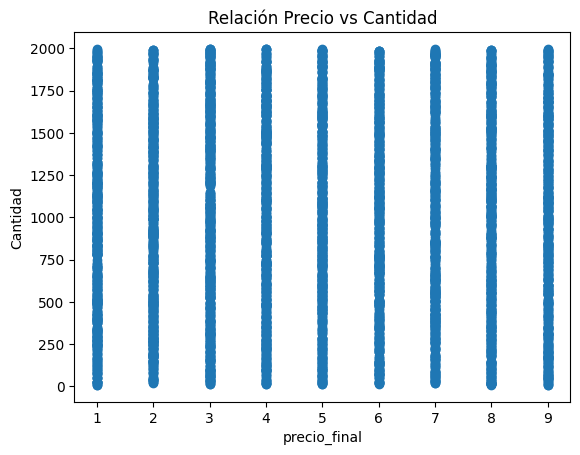

In [65]:
df1_ventas_sucias.info()

## sns.scatterplot(data=df1_ventas_sucias,x="precio_final",y="precio_final")

df2_ventas_sucias = df1_ventas_sucias[df1_ventas_sucias["outlier"]=="no_outlier"]
df2_ventas_sucias = df2_ventas_sucias.sort_values(by="cantidad")

display(df2_ventas_sucias)

plt.scatter(df2_ventas_sucias["cantidad"],df2_ventas_sucias["precio_final"])

plt.xlabel('precio_final')
plt.ylabel('Cantidad')
plt.title('Relación Precio vs Cantidad')
plt.show()

In [57]:
df1_ventas_sucias["precio_final"].describe()

count      4950.000000
mean       5052.507071
std       63380.035413
min          10.000000
25%         537.000000
50%        1027.000000
75%        1512.750000
max      999999.000000
Name: precio_final, dtype: float64

In [58]:
## a csv

df1_ventas_sucias.to_csv("C:\\Users\\juan1\\Downloads\\ventas_limpias_5000.csv", index=False)

### AGRUPEMOS LOS DATOS

Al revisar la gráfica de disperción que nos genera la relacion precio final vs cantidad. vemos datos muy dispersos.

Vamos a agrpar los datos de precio y sumar las cantidades y luego graficar.



,precio_final,cantidad
0,10.0,27.0
1,11.0,1.0
2,12.0,25.0
3,13.0,16.0
4,14.0,4.0
...,...,...
1834,1993.0,1.0
1835,1994.0,3.0
1836,1995.0,12.0
1837,1996.0,22.0


<Axes: xlabel='precio_final', ylabel='cantidad'>

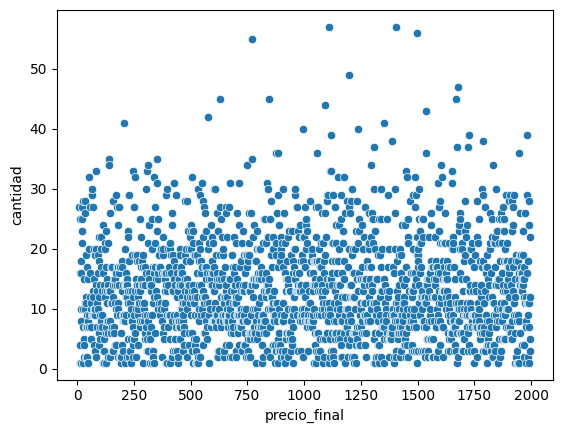

In [81]:
df1_ventas_filtradas= df1_ventas_sucias[df1_ventas_sucias["outlier"]=="no_outlier"]

df1_cantidades_agrupadas = df1_ventas_filtradas.groupby("precio_final")["cantidad"].sum().reset_index()

## el reset index ayuda a que el resultado de la agrupacion vuelva a ser un dataframe y no una serie, ademas de que el precio_final deje de ser el indice y vuelva a ser una columna normal.

display(df1_cantidades_agrupadas)


sns.scatterplot(data=df1_cantidades_agrupadas,x="precio_final",y="cantidad")